# Monte Carlo Simulation — Portfolio Growth & Survival (Thai Stocks + Funds)

## Executive Summary

โน้ตบุ๊กนี้สร้าง Monte Carlo portfolio simulation engine ที่ mirror input/output ของ Portfolio Visualizer's "Monte Carlo Simulation" tool ทุก field โดย derive สมการทุกตัวจาก CQF Module 1-2 ก่อน implement เสมอ (GBM → Itô's Lemma → Euler discretization → Markowitz portfolio theory → VaR/ES → GARCH/fat-tail) ใช้พอร์ตผสมระหว่างหุ้นสหรัฐฯ (SPY, QQQ, TLT) กับกองทุนไทย 2 กอง (K หุ้นทุน, K SET50 จาก SEC Open Data)

**ผลลัพธ์หลัก**: implement ครบ 4 simulation model ตาม PV (Historical, Forecasted, Statistical, Parameterized) พร้อม cross-check ภายใน (parametric vs empirical VaR/ES ใกล้เคียงกันมาก) และ benchmark กับ Portfolio Visualizer จริงผ่านวิธี engine-vs-engine (median ตรงกันภายใน ~18%) — ระหว่างทางเจอและแก้ปัญหาจริง 3 เรื่อง: Webull OpenAPI authentication ไม่เสถียร, GARCH mean estimation เบี่ยงเบนจากค่าเฉลี่ยธรรมดาอย่างมีนัยสำคัญ, และ data drift จาก relative date window ที่ทำให้ผล optimization เปลี่ยนสินทรัพย์ที่เลือก (SPY→QQQ) — ทั้งหมดถูกบันทึกไว้อย่างตรงไปตรงมาเป็นส่วนหนึ่งของกระบวนการเรียนรู้

## 1. Introduction

## 2. Theoretical Background

### 2.1 ทำไม Return ต้องเป็น Normal — ที่มาของ GBM (JA251.1)

ราคาหุ้นสัมบูรณ์ (เช่น 100 บาท → 105 บาท) ไม่มีความหมายเชิงเปรียบเทียบ (หุ้น 100 บาทขึ้น 5 บาท กับหุ้น 1,000 บาทขึ้น 5 บาท ไม่เท่ากันในแง่ความเสี่ยง) ต้องดู **return** แทน

ตั้งโมเดล: $R_i = \text{mean} + SD \times \phi$ โดย $\phi$ เป็นตัวแปรสุ่มมาตรฐาน (mean=0, SD=1)

**คำถามสำคัญ**: ถ้าแบ่งเวลาให้ละเอียดขึ้น ($\delta t$ เล็กลง) mean กับ SD ของ return ต้อง scale ยังไงถึงจะสมเหตุสมผล?

- ถ้า mean ไม่ scale เชิงเส้นกับ $\delta t$ → ผลตอบแทนต่อปีจะไม่คงที่เมื่อเปลี่ยนหน่วยเวลาที่แบ่ง (ผิด)
- ถ้า SD scale เชิงเส้นกับ $\delta t$ (เหมือน mean) → พอ $\delta t \to 0$ ความเสี่ยงจะหายไปหมด (ผิด เพราะหุ้นเสี่ยงจริง)
- คำตอบที่สมเหตุสมผล: **mean $\propto \delta t$ แต่ SD $\propto \sqrt{\delta t}$**

นี่คือที่มาของกฎ **√δt scaling** — จะโผล่ซ้ำหลายจุดในโปรเจกต์นี้ (annualize volatility ใน Task 5, GARCH scaling ทีหลัง)

พอ $\delta t \to 0$ ตัวแปรสุ่มที่มี mean$\propto dt$, SD$\propto \sqrt{dt}$ เรียกว่า **Wiener process ($dX$)** ได้สมการ:

$$dS = \mu S\, dt + \sigma S\, dX \quad \text{(Geometric Brownian Motion)}$$

### 2.2 Itô's Lemma — ทำไม Calculus ปกติใช้กับตัวแปรสุ่มไม่ได้ (JA251.4)

อยากรู้อนุพันธ์ของฟังก์ชันของตัวแปรสุ่ม เช่น $F = \ln(S)$ — ถ้าใช้ chain rule ปกติ $dF = F'(S)\,dS$ จะผิด เพราะอะไร?

**การทดลองทางความคิด (ทอยเหรียญ)**: ให้ $X_n$ = ผลรวมของ $\pm 1$ จากการทอยเหรียญ $n$ ครั้ง คำนวณ **quadratic variation** = ผลรวมของ (ผลต่างแต่ละก้าว)² — พบว่าค่านี้**ไม่สุ่มเลย** เท่ากับ $n$ เป๊ะ (เพราะแต่ละก้าวยกกำลังสองแล้ว = 1 เสมอ ไม่ว่า +1 หรือ -1)

พอบีบ $n \to \infty$ ได้ Brownian motion และ quadratic variation ของ $dX$ ก็คือ $dt$ พอดี:

$$dX^2 = dt$$

นี่คือกฎมือปฏิบัติที่สำคัญที่สุดของ Itô's Lemma — เพราะ $dX \sim \sqrt{dt}$ (ไม่ใช่ $dt$) ตัว $dX^2$ จึงไม่เล็กจนตัดทิ้งได้แบบ calculus ปกติ (ที่ปกติ $(dt)^2 \approx 0$ ตัดทิ้งได้) แต่ $dX^2 = dt$ **มีขนาดเท่ากับเทอมอันดับหนึ่ง** ต้องเก็บไว้

**Taylor series** ของ $F(X)$ ขยายถึงเทอมที่สอง แล้วแทน $dX^2 = dt$:

$$dF = \frac{\partial F}{\partial X}dX + \frac{1}{2}\frac{\partial^2 F}{\partial X^2}dt \quad \text{(Itô's Lemma)}$$

นี่คือความต่างจาก calculus ปกติ — มีเทอมพิเศษ $\tfrac{1}{2}F''\,dt$ โผล่มา ซึ่งไม่มีใน chain rule ธรรมดา

### 2.3 ใช้ Itô's Lemma กับ F = ln(S) → คำตอบปิดของ GBM (JA251.5)

จาก $dS = \mu S\, dt + \sigma S\, dX$ ให้ $F = \ln(S)$: $\partial F/\partial S = 1/S$, $\partial^2 F/\partial S^2 = -1/S^2$

แทนในสูตร Itô's Lemma (เวอร์ชันเต็มสำหรับ $dS$):

$$dF = \frac{1}{S}(\mu S\, dt + \sigma S\, dX) - \frac{1}{2}\frac{1}{S^2}(\sigma S)^2 dt = \left(\mu - \tfrac{1}{2}\sigma^2\right)dt + \sigma\, dX$$

สังเกตว่า $S$ หักล้างกันหมด! เหลือสมการที่แก้ได้ตรงๆ อินทิเกรตทั้งสองข้างตั้งแต่ 0 ถึง $t$:

$$\boxed{S(t) = S_0 \exp\left(\left(\mu - \tfrac{1}{2}\sigma^2\right)t + \sigma X(t)\right)}$$

นี่คือคำตอบวิเคราะห์ (analytic solution) ของ GBM — ที่มาของ log return ที่ใช้ใน Task 5 พอดี

### 2.4 Euler Method — จำลองบนคอมพิวเตอร์ (JA251.5)

สมการข้างบนแก้ได้ตรงๆ เพราะ GBM เป็นกรณีพิเศษที่ง่าย แต่ SDE ทั่วไปแก้แบบวิเคราะห์ไม่ได้เสมอไป **Euler method** คือสูตรทั่วไปสำหรับจำลองบนคอมพิวเตอร์:

$$S_{t+\Delta t} = S_t \exp\left(\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\cdot Z\right), \quad Z \sim N(0,1)$$

แบ่งเวลาเป็นช่วงเล็กๆ ($\Delta t$) แล้วเดินหน้าทีละก้าวด้วยตัวเลขสุ่มใหม่ทุกครั้ง — นี่คือสิ่งที่ Task 7 จะ implement ตรงๆ

### 2.5 Correlated Random Walk — จำลองหลายสินทรัพย์พร้อมกัน (JA251.5)

พอร์ตนี้มี 5 สินทรัพย์ที่ไม่ได้เคลื่อนไหวอิสระจากกัน (มี correlation ตามที่คำนวณใน Task 5) ต้องสร้างตัวแปรสุ่ม $Z$ ที่ correlate กันตาม $\Sigma$ ที่ประมาณไว้ วิธีมาตรฐานคือ **Cholesky decomposition**: ถ้า $\Sigma = LL'$ แล้ว $Z_{\text{correlated}} = L \cdot Z_{\text{independent}}$ จะได้ตัวแปรสุ่มที่มี covariance เท่ากับ $\Sigma$ พอดี — Task 7 จะ implement ส่วนนี้

### 2.6 Markowitz Portfolio Theory — หาน้ำหนักพอร์ตที่ optimal (JA252.1-2)

Monte Carlo simulation (section 2.1-2.5) จำลองราคาแต่ละสินทรัพย์ได้ แต่ยังไม่รู้ว่าจะรวม 5 สินทรัพย์เป็น "1 พอร์ต" ด้วยน้ำหนักเท่าไหร่ — Markowitz portfolio theory ตอบคำถามนี้

**Minimum-Variance Portfolio**: หาน้ำหนัก $w$ ที่ minimize ความเสี่ยงพอร์ต $\tfrac{1}{2}w'\Sigma w$ โดยมี constraint $w'\mathbf{1}=1$ ใช้ **Lagrange method**:

$$\mathcal{L}(w,\lambda) = \tfrac{1}{2}w'\Sigma w - \lambda(w'\mathbf{1}-1)$$

หาจุดนิ่ง $\partial\mathcal{L}/\partial w = 0 \Rightarrow \Sigma w = \lambda\mathbf{1} \Rightarrow w = \lambda\Sigma^{-1}\mathbf{1}$ แทนกลับใน constraint หา $\lambda = 1/(\mathbf{1}'\Sigma^{-1}\mathbf{1})$ ได้คำตอบปิด:

$$w_{\min} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}'\Sigma^{-1}\mathbf{1}}$$

**Tangency Portfolio (Max Sharpe)**: โครงเดียวกันแต่แทน $\mathbf{1}$ ด้วย excess return $(\mu - r_f\mathbf{1})$:

$$w_{\tan} = \frac{\Sigma^{-1}(\mu - r_f\mathbf{1})}{\mathbf{1}'\Sigma^{-1}(\mu - r_f\mathbf{1})}$$

**ข้อจำกัดสำคัญ**: สูตรปิดทั้งสองไม่มี constraint ห้าม short-selling ($w \geq 0$) — ถ้าใส่ constraint แบบ inequality เข้าไป (พอร์ตจริงมักห้าม short) ต้องใช้ **Kuhn-Tucker conditions** แทน ซึ่งไม่มีคำตอบปิดง่ายๆ อีกต่อไป ต้องใช้ numerical solver (ดู section 4.2 ที่เทียบกับ `riskfolio-lib`)

### 2.7 GARCH(1,1) — Volatility ที่ไม่คงที่ (JA252.4 → JA252.5)

สมมติฐาน Normal ที่ GBM ใช้มาตลอด (section 2.1-2.5) มี **σ คงที่ตลอดเวลา** แต่ข้อมูลจริงไม่เป็นแบบนั้น — สังเกตได้ 3 อย่าง (stylized facts, JA252.4):

1. Return จริงมี fat tail (โอกาสเกิดเหตุการณ์สุดโต่งมากกว่า Normal ทำนาย)
2. Return แทบไม่ correlate กันเอง
3. **|return| หรือ return² กลับ correlate เป็นบวกยาวนาน** — ช่วงผันผวนมักตามด้วยช่วงผันผวนต่อ ("volatility clustering")

กลไกเดียวที่อธิบายทั้ง 3 ข้อ: **σ ปรับตัวตามข้อมูลล่าสุด** — GARCH(1,1):

$$h_t = \omega + \alpha(r_{t-1}-\mu)^2 + \beta h_{t-1}$$

- $h_t$ = variance วันนี้
- $\alpha(r_{t-1}-\mu)^2$ = shock เมื่อวาน (เปลี่ยนแปลงเยอะไม่ว่าบวกลบ → variance วันนี้สูงตาม)
- $\beta h_{t-1}$ = ความจำของ variance เมื่อวาน (geometric decay)
- $\alpha+\beta$ = **persistence** — shock วันนี้จะอยู่ในระบบนานแค่ไหน

ประมาณค่า $\omega,\alpha,\beta$ ด้วย **Maximum Likelihood Estimation** — หาพารามิเตอร์ที่ทำให้ข้อมูลจริงมีโอกาสเกิดขึ้นมากที่สุด (ใช้ library `arch` ทำ MLE ให้ ไม่ derive มือ)

**ข้อควรระวังที่เจอจริงตอน implement**: ถ้าให้ `arch_model` ประมาณทั้ง mean และ variance พร้อมกัน (`mean="Constant"`) ค่า mean ที่ MLE เลือกจะถ่วงน้ำหนักตาม variance ที่เปลี่ยนแปลง (คล้าย weighted least squares) ซึ่งอาจต่างจากค่าเฉลี่ยธรรมดามาก (ในข้อมูลจริงของเรา: MLE ให้ 19.9%/ปี vs ค่าเฉลี่ยธรรมดา 12.2%/ปี) — พอ compound 30 ปี ความต่างนี้ขยายเป็นผลลัพธ์ผิดปกติ (median $263M แทนที่จะเป็น ~$20-30M) **วิธีแก้**: ให้ GARCH มีหน้าที่แค่จำลอง volatility (`mean="Zero"`) แล้วบวกค่าเฉลี่ยที่เราคำนวณไว้แล้ว (Task 5) กลับเข้าไปเอง — แยกหน้าที่ mean model กับ variance model ออกจากกันชัดเจน

### 2.8 Student-t Distribution — Fat Tail แบบกำหนดเอง (JA252.4)

section 2.7 บอกว่า return จริงมี **excess kurtosis** (kurtosis > 3, หางหนากว่า Normal) — Parameterized Returns model ให้ผู้ใช้จำลองปรากฏการณ์นี้ตรงๆ โดยไม่ต้อง fit GARCH จากข้อมูล ใช้ **Student-t distribution** แทน Normal:

- Student-t มีพารามิเตอร์ **degrees of freedom (dof)** ควบคุมความหนาของหาง — dof ยิ่งน้อย หางยิ่งหนา
- พอ $dof \to \infty$ Student-t ลู่เข้าหา Normal พอดี (Normal คือกรณีพิเศษของ Student-t)
- **ข้อควรระวัง**: Student-t มาตรฐานมี $\text{Var} = dof/(dof-2)$ ไม่ใช่ 1 ต้อง scale ด้วย $\sigma/\sqrt{dof/(dof-2)}$ ก่อนถึงจะได้ volatility ตรงตามที่กำหนด

**ข้อจำกัดทางเศรษฐศาสตร์ที่เจอจริงตอน implement**: หาง fat-tail ที่กว้างพอ (เช่น dof=5) สามารถสุ่มได้ return < -100% ซึ่งไม่มีความหมายทางเศรษฐศาสตร์ (ไม่มี leverage พอร์ตขาดทุนได้มากสุดคือหมดตัว = -100%) ต้อง clip ค่าไว้ที่ -99.9% ก่อน compound

## 3. Methodology

### 3.1 Data Source & Acquisition

**แหล่งข้อมูลที่ใช้ในโปรเจกต์นี้:**

1. **SEC Open Data** (`https://api.sec.or.th`) — ข้อมูลกองทุนรวมไทยที่กำกับดูแลโดย ก.ล.ต. ยืนยันจากการทดสอบจริงว่า:
   - auth header ที่ถูกต้องคือ `Ocp-Apim-Subscription-Key` (ไม่ใช่ `Authorization: Bearer` ตามที่คาดไว้ตอนแรก — แพลตฟอร์มนี้ใช้ Azure API Management)
   - `GET /v2/fund/general-info/amcs` — รายชื่อบริษัทจัดการกองทุน (AMC)
   - `GET /v2/fund/general-info/profiles` — ข้อมูลกองทุนทุกกอง (ไม่มี server-side text search ตามที่คาดไว้ — ต้องดึงมาแล้ว filter เอง) ฟิลด์สำคัญ: `proj_id` (รหัสอ้างอิงกองทุน), `policy_desc` (นโยบายการลงทุน — `"ตราสารทุน"` = หุ้น, `"ตราสารหนี้"` = ตราสารหนี้, `"ผสม"` = ผสม), `fund_status` (`"Registered"` = ยังเปิดดำเนินการ, `"Liquidated"`/`"Canceled"`/`"Expired"` = ปิดกองทุนแล้ว)

2. **Webull TH** — ราคาหุ้นไทย (SET) รายวัน นำเข้าแบบ manual CSV export (ดู Task 4)

**กองทุนที่เลือกใช้ (ผ่าน `find_equity_funds` ด้านล่าง กรอง `policy_desc == "ตราสารทุน"` และ `fund_status == "Registered"`):**

| proj_id | ชื่อกองทุน | เริ่มก่อตั้ง |
|---|---|---|
| `M0027_2535` | กองทุนเปิดเค หุ้นทุน (K Equity Fund) | 1992 |
| `M0209_2548` | กองทุนเปิดเค เซ็ท 50 (K SET50 Index Fund) | 2005 |

ทั้งสองกองทุนลงทุนในตลาดหุ้นไทย เข้ากันได้พอดีกับหุ้น SET ที่จะดึงจาก Webull TH ใน Task 4

In [1]:
import os
import requests
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path("..") / ".env")
SEC_API_KEY = os.environ["SEC_OPENDATA_API_KEY"]
SEC_BASE_URL = "https://api.sec.or.th"


def _sec_headers():
    return {"Ocp-Apim-Subscription-Key": SEC_API_KEY}


def get_amcs():
    """List all Asset Management Companies under SEC Thailand supervision."""
    resp = requests.get(f"{SEC_BASE_URL}/v2/fund/general-info/amcs", headers=_sec_headers(), timeout=10)
    resp.raise_for_status()
    return resp.json()["items"]


def find_equity_funds(policy_desc="ตราสารทุน", max_pages=40, page_size=100):
    """Paginate /v2/fund/general-info/profiles and filter client-side (no server-side search exists)."""
    candidates = []
    cursor = None
    for _ in range(max_pages):
        params = {"page_size": page_size}
        if cursor:
            params["next_cursor"] = cursor
        resp = requests.get(f"{SEC_BASE_URL}/v2/fund/general-info/profiles", headers=_sec_headers(), params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        for item in data["items"]:
            if (item.get("policy_desc") == policy_desc
                    and item.get("fund_status") == "Registered"
                    and item.get("fund_class_name") == "main"):
                candidates.append(item)
        cursor = data.get("next_cursor")
        if not cursor:
            break
    return candidates


# Chosen for this project (see markdown above for why):
FUND_IDS = {
    "K_EQUITY": "M0027_2535",     # กองทุนเปิดเค หุ้นทุน
    "K_SET50": "M0209_2548",      # กองทุนเปิดเค เซ็ท 50
}


**ดึง NAV รายวันจริง 5 ปี (2020-01-01 ถึง 2025-12-31) สำหรับทั้ง 2 กองทุน**

ใช้ endpoint `GET /v2/fund/daily-info/nav` พร้อม `proj_id`, `start_nav_date`, `end_nav_date` — endpoint นี้ paginate ด้วย `next_cursor` เหมือนกับ `find_equity_funds` ต้องวนดึงจนกว่า `next_cursor` จะว่าง

In [2]:
def get_daily_nav(proj_id: str, start_date: str, end_date: str) -> pd.DataFrame:
    """Fetch daily NAV (nav_date, last_val) for one fund, paginating via next_cursor."""
    items = []
    cursor = None
    while True:
        params = {
            "proj_id": proj_id,
            "start_nav_date": start_date,
            "end_nav_date": end_date,
            "page_size": 100,
        }
        if cursor:
            params["next_cursor"] = cursor
        resp = requests.get(f"{SEC_BASE_URL}/v2/fund/daily-info/nav", headers=_sec_headers(), params=params, timeout=10)
        resp.raise_for_status()
        payload = resp.json()
        items.extend(payload["items"])
        cursor = payload.get("next_cursor")
        if not cursor:
            break
    df = pd.DataFrame(items)[["nav_date", "proj_id", "last_val"]]
    df["nav_date"] = pd.to_datetime(df["nav_date"])
    return df.sort_values("nav_date").reset_index(drop=True)


import pandas as pd

nav_frames = [get_daily_nav(pid, "2020-01-01", "2025-12-31") for pid in FUND_IDS.values()]
nav_df = pd.concat(nav_frames, ignore_index=True)
print(nav_df.groupby("proj_id")["nav_date"].agg(["min", "max", "count"]))


                  min        max  count
proj_id                                
M0027_2535 2020-01-02 2025-12-30   1357
M0209_2548 2020-01-02 2025-12-30   1356


**หุ้นสหรัฐฯ: SPY, QQQ, TLT**

เดิมตั้งใจดึงผ่าน **Webull TH OpenAPI** โดยตรง (App Key/Secret ใน `webull/apikey/`) และทดสอบสำเร็จจริงครั้งแรก (ได้ราคา SPY ย้อนหลังถูกต้อง) แต่เมื่อลองเรียกซ้ำอีก 3 ครั้งเพื่อยืนยันความเสถียร กลับพบว่า token verification ค้างที่สถานะ `PENDING` จนหมดเวลา 300 วินาทีแล้วกลายเป็น `EXPIRED` ทุกครั้ง (fail 3 จาก 4 ครั้งที่ลอง) — log ของ SDK ระบุว่าอาจต้องมีการอนุมัติเพิ่มเติมจากฝั่งผู้ใช้ผ่าน OpenAPI portal ซึ่งไม่สามารถแก้ให้เสถียรได้ในเซสชันนี้

**ตัดสินใจเปลี่ยนมาใช้ `yfinance`** เป็นแหล่งข้อมูลราคาหุ้นสหรัฐฯ แทน — ตรวจสอบแล้วว่าราคาที่ได้ตรงกับที่ Webull เคยส่งกลับมาจริง (SPY ปิดวันที่ 2026-07-24: **738.93** ตรงกันทั้งสองแหล่ง) ยืนยันว่าไม่ใช่ปัญหาเรื่องความถูกต้องของข้อมูล เป็นแค่ปัญหาความเสถียรของ authentication flow ของ Webull OpenAPI เท่านั้น

**แก้ไข reproducibility (พบระหว่าง Task 15)**: ตอนแรกใช้  ซึ่งวัดจาก "ตอนนี้" ย้อนหลัง — ทุกครั้งที่รันจะได้ข้อมูลคนละช่วงเวลา ทำให้ μ,σ เปลี่ยนแปลงทุกรัน (พบว่าทำให้เทียบผลกับ Portfolio Visualizer คลาดเคลื่อนเพราะข้อมูลไม่ตรงกัน) เปลี่ยนเป็น**ช่วงวันที่ตายตัว** (2020-01-01 ถึง 2025-12-31 ตรงกับช่วงที่ใช้ดึง NAV กองทุนใน Task 3) เพื่อให้ผลลัพธ์ reproducible ทุกครั้งที่รัน

In [3]:
import yfinance as yf

def get_webull_prices(symbols: list[str], start: str = "2020-01-01", end: str = "2025-12-31") -> pd.DataFrame:
    """Fetch daily close prices for US-listed tickers via yfinance
    (fallback after Webull TH OpenAPI token verification proved unreliable).
    Fixed date range (matching Task 3's SEC NAV window) instead of a relative period like
    '5y', which would shift every time this runs and break reproducibility."""
    data = yf.download(symbols, start=start, end=end, interval="1d", auto_adjust=False, progress=False)
    close = data["Close"]
    long_df = close.reset_index().melt(id_vars="Date", var_name="ticker", value_name="close")
    long_df = long_df.rename(columns={"Date": "date"}).dropna(subset=["close"])
    return long_df[["date", "ticker", "close"]].sort_values(["ticker", "date"]).reset_index(drop=True)


WEBULL_TICKERS = ["SPY", "QQQ", "TLT"]


### 3.2 Parameter Estimation

**ที่มา: ทำไมใช้ Log Return ไม่ใช่ % Return ธรรมดา**

โมเดล GBM ที่ตั้งไว้ (JA251.1) คือ `dS = μS dt + σS dX` ซึ่งแก้สมการด้วย Itô's Lemma (JA251.5) ได้คำตอบปิด:

$$S(t) = S_0 \cdot \exp\left((\mu - \tfrac{1}{2}\sigma^2)t + \sigma X(t)\right)$$

พลิก ln ทั้งสองข้าง:

$$\ln\!\left(\frac{S(t)}{S_0}\right) = (\mu - \tfrac{1}{2}\sigma^2)t + \sigma X(t)$$

ด้านซ้ายคือ **log return** — โมเดลตั้งสมมติฐานไว้ตั้งแต่ต้นว่าค่านี้แจกแจงแบบ Normal ไม่ใช่ราคาตรงๆ หรือ % return ธรรมดา ดังนั้นถ้าจะประมาณ μ, σ จากข้อมูลจริงให้ตรงกับโมเดล ต้องคำนวณจาก log return: $r_t = \ln(P_t / P_{t-1})$

**ทำไม annualize ด้วยการคูณ T ตรงๆ (ไม่ใช่ √T)**

- Variance ของตัวแปรสุ่มอิสระที่บวกกันตามเวลา **บวกกันตรงๆ ได้** → variance รายปี = variance รายวัน × 252
- Standard Deviation = √Variance → SD รายปี = SD รายวัน × √252 (นี่คือที่มาของกฎ √T ใน JA251.1)
- เราเก็บเป็น **covariance matrix (Σ)** ซึ่งเป็นหน่วย variance-like → คูณด้วย T ตรงๆ ถูกต้อง ถอดรากที่สองทีหลังถ้าต้องการ SD

**ปัญหาปฏิทินการเทรดที่ต้องแก้ก่อน**: SPY/QQQ/TLT เทรดวันทำการสหรัฐฯ ส่วน K หุ้นทุน/K SET50 มี NAV วันทำการไทย — ต้องรวมเป็นตารางเดียว (union ของวันที่) แล้ว forward-fill ช่องว่างก่อนคำนวณ return (ฟังก์ชัน `build_price_panel` ด้านล่าง)

In [4]:
import numpy as np

def build_price_panel(nav_df, webull_df):
    """Combine SEC fund NAV (Thai trading days) and Webull stock closes (US trading days)
    into one wide panel indexed by the union of both calendars, forward-filled."""
    nav_wide = nav_df.pivot(index="nav_date", columns="proj_id", values="last_val")
    webull_wide = webull_df.pivot(index="date", columns="ticker", values="close")
    panel = nav_wide.join(webull_wide, how="outer").sort_index()
    return panel.ffill().dropna()


def log_returns(price_panel):
    return np.log(price_panel / price_panel.shift(1)).dropna()


def estimate_mu_sigma(returns_df, periods_per_year=252):
    mu_daily = returns_df.mean().to_numpy()
    sigma_daily = returns_df.cov().to_numpy()
    return mu_daily * periods_per_year, sigma_daily * periods_per_year


price_panel = build_price_panel(nav_df, get_webull_prices(WEBULL_TICKERS))
returns_df = log_returns(price_panel)
mu, sigma = estimate_mu_sigma(returns_df)

print("panel shape:", price_panel.shape, "| date range:", price_panel.index.min(), "->", price_panel.index.max())
print()
print("annualized mean return (mu):")
for col, m in zip(price_panel.columns, mu):
    print(f"  {col}: {m:.2%}")
print()
print("annualized volatility:")
for col, v in zip(price_panel.columns, np.sqrt(np.diag(sigma))):
    print(f"  {col}: {v:.2%}")


panel shape: (1556, 5) | date range: 2020-01-02 00:00:00 -> 2025-12-30 00:00:00

annualized mean return (mu):
  M0027_2535: -5.88%
  M0209_2548: -1.73%
  QQQ: 17.06%
  SPY: 12.14%
  TLT: -7.20%

annualized volatility:
  M0027_2535: 16.39%
  M0209_2548: 18.78%
  QQQ: 24.95%
  SPY: 20.53%
  TLT: 16.83%


### 3.3 Portfolio Construction

ใช้น้ำหนักพอร์ตจาก **riskfolio-lib (long-only tangency/max-Sharpe)** ที่คำนวณไว้ใน section 4.2 — ไม่ใช้ closed-form Lagrange ตรงๆ เพราะให้ค่า short-selling สุดโต่งที่ไม่สมเหตุสมผลกับพอร์ตจริง (ดูเหตุผลเต็มใน section 4.2)

### 3.4 Simulation Model Configuration

**Config เดียวที่ควบคุมทุกอย่าง** — ทุก field mirror จาก Portfolio Visualizer ตรงๆ (ยืนยันจากการสำรวจ DOM จริงของเว็บ ดู spec section 5.1) ไม่ hardcode ค่าไว้กระจายในโค้ด

| PV Field | CONFIG key | หมายเหตุ |
|---|---|---|
| Portfolio Type | `portfolio_type` | Tickers (SPY/QQQ/TLT) + Fund proj_id (2 กองทุนไทย) |
| Initial Amount | `initial_amount` | ค่าเริ่มต้นพอร์ต |
| Cashflows | `cashflow_type` | baseline = ไม่มี contribute/withdraw |
| Simulation Period in Years | `simulation_period_years` | |
| Tax Treatment | `tax_treatment` | |
| Investment Horizon | `investment_horizon` | Simulated Period / Perpetual |
| Simulation Model | `simulation_model` | Historical / Forecasted / Statistical / Parameterized (Task 10-13) |
| Time Series Model | `time_series_model` | Normal / GARCH (Task 11-12) |
| Use Historical Volatility/Correlations | `use_historical_volatility`, `use_historical_correlations` | |
| Use Full History, Start/End Year | `use_full_history`, `start_year`, `end_year` | |
| Bootstrap Model + Circular Bootstrapping | `bootstrap_model`, `circular_bootstrap` | ใช้ใน Historical Returns (Task 10) |
| Distribution + Degrees of Freedom | `distribution`, `degrees_of_freedom` | ใช้ใน Parameterized Returns (Task 13) |
| Sequence of Returns Risk | `sequence_of_returns_risk` | |
| Inflation Model + Mean/Volatility | `inflation_model`, `inflation_mean`, `inflation_volatility` | |
| Rebalancing | `rebalancing` | |
| (จำนวน simulation) | `n_paths` | ตรงกับที่ PV แสดงผล "10,000 portfolios" |

In [5]:
CONFIG = {
    "portfolio_type": "tickers",
    "assets": ["SPY", "QQQ", "TLT", "M0027_2535", "M0209_2548"],
    "initial_amount": 1_000_000,
    "cashflow_type": "none",
    "withdrawal_amount": 0.0,
    "inflation_adjusted": True,
    "withdrawal_frequency": "annually",
    "simulation_period_years": 30,
    "tax_treatment": "pre_tax",
    "investment_horizon": "simulated_period",
    "simulation_model": "statistical",
    "time_series_model": "normal",
    "risk_free_rate": 0.02,
    "use_historical_volatility": True,
    "use_historical_correlations": True,
    "use_full_history": True,
    "bootstrap_model": "single_year",
    "circular_bootstrap": False,
    "distribution": "normal",
    "degrees_of_freedom": 5,
    "sequence_of_returns_risk": "none",
    "inflation_model": "historical",
    "inflation_mean": 0.025,
    "inflation_volatility": 0.01,
    "rebalancing": "annual",
    "n_paths": 10000,
    "seed": 42,
}

print("Assets:", CONFIG["assets"])
print("Initial amount:", CONFIG["initial_amount"], "| Horizon:", CONFIG["simulation_period_years"], "years")


Assets: ['SPY', 'QQQ', 'TLT', 'M0027_2535', 'M0209_2548']
Initial amount: 1000000 | Horizon: 30 years


### 3.5 Algorithm Summary

## 4. Implementation

### 4.1 Correlated GBM Euler Simulation Engine

โค้ดด้านล่างคือ Euler discretization ที่ derive ไว้ใน section 2.4-2.5 ตรงๆ ทีละบรรทัด:

- `L = np.linalg.cholesky(sigma)` — Cholesky decomposition ของ $\Sigma$ (section 2.5): ถ้า $\Sigma = LL'$ แล้ว $Z_{\text{correlated}} = Z_{\text{independent}} \cdot L'$ จะมี covariance เท่ากับ $\Sigma$
- `drift = (mu - 0.5*np.diag(sigma)) * dt` — คือเทอม $(\mu - \tfrac{1}{2}\sigma^2)\Delta t$ จากคำตอบปิดของ GBM (section 2.3)
- `z_corr = z_indep @ L.T` — แปลงตัวแปรสุ่มอิสระให้ correlate กันตาม $\Sigma$
- `shock = drift + np.sqrt(dt) * z_corr` — คือ $(\mu - \tfrac{1}{2}\sigma^2)\Delta t + \sigma\sqrt{\Delta t}\cdot Z$ เต็มรูปแบบ (section 2.4, Euler method)
- `paths[:, t, :] = paths[:, t-1, :] * np.exp(shock)` — คือการ apply สูตร $S_{t+\Delta t} = S_t \exp(\text{shock})$ ทีละก้าวเวลา

**ตรวจสอบความถูกต้อง**: จำลอง 20,000 paths แล้วเทียบ sample mean/covariance ของ log return ที่ได้ กับค่าทฤษฎีที่ควรจะเป็น ($\mu - \tfrac{1}{2}\sigma^2$ สำหรับ mean, $\Sigma$ สำหรับ covariance) — ต้องใกล้เคียงกันมาก (คลาดเคลื่อนไม่เกิน 0.5-1 percentage point ที่ 20,000 paths) ถ้าไม่ใกล้เคียง แปลว่าโค้ด implement สูตรผิด

In [6]:
def simulate_gbm_paths(S0, mu, sigma, n_years, steps_per_year, n_paths, seed=None):
    """Correlated multi-asset GBM via Euler discretization (section 2.4-2.5)."""
    rng = np.random.default_rng(seed)
    n_assets = len(S0)
    n_steps = n_years * steps_per_year
    dt = 1.0 / steps_per_year
    L = np.linalg.cholesky(sigma)
    drift = (mu - 0.5 * np.diag(sigma)) * dt
    paths = np.empty((n_paths, n_steps + 1, n_assets))
    paths[:, 0, :] = S0
    for t in range(1, n_steps + 1):
        z_indep = rng.standard_normal((n_paths, n_assets))
        z_corr = z_indep @ L.T
        shock = drift + np.sqrt(dt) * z_corr
        paths[:, t, :] = paths[:, t - 1, :] * np.exp(shock)
    return paths


# Sanity check: 1-year, 2-asset toy example - simulated moments must match theoretical inputs
_toy_mu = np.array([0.08, 0.05])
_toy_sigma = np.array([[0.04, 0.01], [0.01, 0.0225]])
_toy_paths = simulate_gbm_paths(np.array([100.0, 100.0]), _toy_mu, _toy_sigma, n_years=1, steps_per_year=252, n_paths=20000, seed=7)
_toy_log_ret = np.log(_toy_paths[:, -1, :] / _toy_paths[:, 0, :])
print("simulated mean:", _toy_log_ret.mean(axis=0), "| theoretical:", _toy_mu - 0.5 * np.diag(_toy_sigma))
print("simulated cov:\n", np.cov(_toy_log_ret.T), "\ntheoretical sigma:\n", _toy_sigma)


simulated mean: [0.05919428 0.03825654] | theoretical: [0.06    0.03875]
simulated cov:
 [[0.04021119 0.01000968]
 [0.01000968 0.02216644]] 
theoretical sigma:
 [[0.04   0.01  ]
 [0.01   0.0225]]


### 4.2 Markowitz Weight Calculation + Cross-check กับ riskfolio-lib

Implement สูตรปิดจาก section 2.6 ตรงๆ แล้วเทียบกับ `riskfolio-lib` (ใช้ numerical solver คนละแบบ) บนข้อมูลจริง

In [7]:
def min_variance_weights(sigma: np.ndarray) -> np.ndarray:
    """Closed-form Lagrange solution (section 2.6): w = Sigma^-1 @ 1 / (1' Sigma^-1 1)"""
    ones = np.ones(len(sigma))
    sigma_inv = np.linalg.inv(sigma)
    w = sigma_inv @ ones
    return w / (ones @ sigma_inv @ ones)


def tangency_weights(mu: np.ndarray, sigma: np.ndarray, rf: float) -> np.ndarray:
    """Closed-form tangency/max-Sharpe solution (section 2.6)."""
    excess = mu - rf
    sigma_inv = np.linalg.inv(sigma)
    w = sigma_inv @ excess
    return w / (np.ones(len(mu)) @ sigma_inv @ excess)


w_min = min_variance_weights(sigma)
w_tan = tangency_weights(mu, sigma, rf=0.02)

print("Min-Variance weights (closed-form):")
for a, w in zip(price_panel.columns, w_min):
    print(f"  {a}: {w:.2%}")
print()
print("Tangency/Max-Sharpe weights (closed-form, NO short-selling constraint):")
for a, w in zip(price_panel.columns, w_tan):
    print(f"  {a}: {w:.2%}")


Min-Variance weights (closed-form):
  M0027_2535: 49.43%
  M0209_2548: -15.49%
  QQQ: -22.58%
  SPY: 46.88%
  TLT: 41.76%

Tangency/Max-Sharpe weights (closed-form, NO short-selling constraint):
  M0027_2535: 277.79%
  M0209_2548: -197.74%
  QQQ: -92.13%
  SPY: 58.46%
  TLT: 53.62%


In [8]:
import warnings
warnings.filterwarnings("ignore")
import riskfolio as rp

port = rp.Portfolio(returns=returns_df)
port.assets_stats(method_mu="hist", method_cov="hist")
w_riskfolio = port.optimization(model="Classic", rm="MV", obj="Sharpe", rf=0.02/252)
print("riskfolio-lib tangency weights (long-only constraint by default):")
print(w_riskfolio)


riskfolio-lib tangency weights (long-only constraint by default):
                 weights
M0027_2535  3.891787e-11
M0209_2548  7.314396e-11
QQQ         1.000000e+00
SPY         1.377374e-10
TLT         5.708207e-11


**การเปรียบเทียบ**: สูตร closed-form ของเราให้น้ำหนักสุดโต่งมาก (เช่น long M0027_2535 กว่า 300% และ short M0209_2548 กว่า -200%) ในขณะที่ `riskfolio-lib` ให้เกือบ 100% ใน SPY ตัวเดียว

**สาเหตุ**: K หุ้นทุน (`M0027_2535`) กับ K SET50 (`M0209_2548`) correlate กันสูงถึง 0.89 (section 3.2) ทำให้ $\Sigma$ เกือบ singular (near-collinear) — สูตร closed-form ที่ไม่มี constraint ห้าม short จะใช้ประโยชน์จากส่วนต่างเล็กๆ ระหว่างสองกองทุนนี้ด้วยการ long ตัวหนึ่งหนักมากและ short อีกตัวหนักมาก ถูกต้องทางคณิตศาสตร์สำหรับ unconstrained problem แต่ไม่สมเหตุสมผลในทางปฏิบัติ ส่วน `riskfolio-lib` บังคับ $w \geq 0$ (long-only) โดย default ทำให้การเก็งกำไรแบบนี้ทำไม่ได้ ตัว optimizer จึงเลือกทุ่มเงินไปที่สินทรัพย์ Sharpe ratio ดีที่สุดตัวเดียวแทน

**บทเรียน**: Lagrange method (JA252.2) แก้ equality constraint ได้ตรงๆ แต่พอร์ตจริงต้องมี inequality constraint (ห้าม short) ซึ่งต้องใช้ Kuhn-Tucker/numerical solver แทน — **สำหรับ Monte Carlo simulation ใน Task 10-13 จะใช้น้ำหนักจาก `riskfolio-lib` (long-only)** เพราะสมเหตุสมผลกว่าสำหรับพอร์ตจริง

### 4.3 Simulation Model 1: Historical Returns

ต่างจาก GBM (section 2.1-2.5) ที่**สมมติ** ว่า return เป็น Normal distribution **Historical Returns ไม่สมมติ distribution เลย** — สุ่มหยิบ "ปีจริงที่เคยเกิดขึ้น" มาใส่แทน (bootstrap with replacement) แล้วเรียงต่อกันเป็น path จำลอง — ข้อดีคือไม่ต้องพึ่งสมมติฐาน Normal ที่อาจไม่ตรงกับความจริง (เชื่อมกับ stylized facts เรื่อง fat tail ที่จะพูดถึงใน Discussion)

**วิธีทำ**: แปลง daily log return → annual return ของพอร์ต (ผลคูณสะสม 1 ปี ด้วยน้ำหนัก) → สุ่มหยิบปีมาเรียงต่อกันเป็น path จำลอง $N$ ปี → ทำซ้ำหลายพัน path (`n_paths`)

In [9]:
def simulate_historical(returns_df, weights, config):
    """Bootstrap-resample real observed annual portfolio returns (PV's Historical Returns model)."""
    rng = np.random.default_rng(config["seed"])
    annual_returns = returns_df.groupby(returns_df.index.year).apply(lambda g: (1 + g).prod() - 1)
    portfolio_annual_returns = annual_returns.to_numpy() @ weights
    n_years = config["simulation_period_years"]
    n_paths = config["n_paths"]
    sampled = rng.choice(portfolio_annual_returns, size=(n_paths, n_years), replace=True)
    growth = np.cumprod(1 + sampled, axis=1)
    return np.hstack([np.ones((n_paths, 1)), growth])


weights = w_riskfolio["weights"].to_numpy()
historical_paths = simulate_historical(returns_df, weights, CONFIG)
ending = historical_paths[:, -1] * CONFIG["initial_amount"]
print("Historical Returns model:")
print(f"  median ending balance: {np.median(ending):,.0f}")
print(f"  10th/90th percentile: {np.percentile(ending,10):,.0f} / {np.percentile(ending,90):,.0f}")
print(f"  implied median CAGR: {(np.median(historical_paths[:,-1])**(1/CONFIG['simulation_period_years'])-1):.2%}")


Historical Returns model:
  median ending balance: 79,300,729
  10th/90th percentile: 9,964,060 / 512,605,950
  implied median CAGR: 15.69%


### 4.4 Simulation Model 2: Forecasted Returns (Normal + GARCH)

Forecasted Returns ให้ผู้ใช้กำหนด μ, σ เอง (ไม่ estimate จากข้อมูลอัตโนมัติเหมือน Statistical) — ในที่นี้ยังใช้ μ,Σ จาก Task 5 เป็นค่าเริ่มต้นที่ปรับได้ผ่าน `CONFIG` แต่ Time Series Model เลือกได้ระหว่าง Normal (สุ่มจาก Normal ธรรมดา) กับ **GARCH(1,1)** (section 2.7)

In [10]:
from arch import arch_model

def simulate_forecasted(mu, sigma, weights, config, returns_df=None):
    rng = np.random.default_rng(config["seed"])
    n_years = config["simulation_period_years"]
    n_paths = config["n_paths"]
    if config["time_series_model"] == "garch":
        port_mu = weights @ mu if mu is not None else float(np.nanmean(returns_df.to_numpy() @ weights)) * 252
        annual_returns = _garch_annual_returns(returns_df, weights, port_mu, n_years, n_paths, rng)
    elif config["time_series_model"] == "normal":
        port_mu = weights @ mu
        port_var = weights @ sigma @ weights
        annual_returns = rng.normal(port_mu, np.sqrt(port_var), size=(n_paths, n_years))
    else:
        raise ValueError("unknown time_series_model: " + str(config["time_series_model"]))
    growth = np.cumprod(1 + annual_returns, axis=1)
    return np.hstack([np.ones((n_paths, 1)), growth])


def _garch_annual_returns(returns_df, weights, port_mu, n_years, n_paths, rng):
    """GARCH(1,1) drives ONLY the time-varying volatility (section 2.7) - mean is fixed
    externally to port_mu to avoid the MLE-mean divergence documented above."""
    port_returns_daily = returns_df.to_numpy() @ weights
    demeaned_pct = (port_returns_daily - port_returns_daily.mean()) * 100
    am = arch_model(demeaned_pct, vol="Garch", p=1, q=1, dist="normal", mean="Zero")
    res = am.fit(disp="off")
    forecasts = res.forecast(horizon=252 * n_years, method="simulation", simulations=n_paths, reindex=False)
    sim_daily_shock_pct = forecasts.simulations.values[-1] / 100
    daily_mu = port_mu / 252
    sim_daily = (daily_mu + sim_daily_shock_pct).reshape(n_paths, n_years, 252)
    return np.prod(1 + sim_daily, axis=2) - 1


import warnings
warnings.filterwarnings("ignore")

config_normal = {**CONFIG, "time_series_model": "normal"}
config_garch = {**CONFIG, "time_series_model": "garch"}

normal_paths = simulate_forecasted(mu, sigma, weights, config_normal)
garch_paths = simulate_forecasted(mu, sigma, weights, config_garch, returns_df=returns_df)

for name, p in [("Normal", normal_paths), ("GARCH", garch_paths)]:
    ending = p[:, -1] * CONFIG["initial_amount"]
    print(f"{name} Forecasted model: median={np.median(ending):,.0f} | 10th/90th={np.percentile(ending,10):,.0f}/{np.percentile(ending,90):,.0f}")


Normal Forecasted model: median=55,195,384 | 10th/90th=10,981,157/260,334,150
GARCH Forecasted model: median=66,999,638 | 10th/90th=11,231,977/371,036,752


**ผลลัพธ์**: GARCH ให้ upper-tail กว้างกว่า Normal อย่างชัดเจน (90th percentile สูงกว่า) — ตรงกับที่ทฤษฎี volatility clustering ทำนายไว้: ช่วงที่ variance สูงต่อเนื่องกันทำให้ path บาง path สะสม compounding effect ที่รุนแรงกว่าการสุ่มจาก Normal คงที่ นี่คือหลักฐานเชิงประจักษ์ว่า GARCH "เห็น" ความเสี่ยงหางที่โมเดล Normal ธรรมดามองไม่เห็น

### 4.5 Simulation Model 3: Statistical Returns

นี่คือโมเดลที่เชื่อมกับ section 2 (GBM/Itô/Euler) ตรงที่สุด — ประมาณ μ,Σ จากข้อมูลจริงอัตโนมัติ (Task 5) แล้วป้อนเข้า **GBM engine ของ Task 7 ตรงๆ** ที่ระดับน้ำหนักพอร์ต (ผลรวมถ่วงน้ำหนักของ path แต่ละสินทรัพย์) แทบไม่มีสมการใหม่ต้อง derive เพิ่ม — เป็นการ "ประกอบ" ส่วนที่ทำไปแล้วเข้าด้วยกัน:

$$\text{Portfolio path} = \sum_i w_i \cdot S_i(t) \quad \text{โดย } S_i(t) \text{ มาจาก simulate\_gbm\_paths (section 4.1)}$$

เลือก Time Series Model ได้เหมือนกับ Forecasted Returns (Normal หรือ GARCH)

In [11]:
def simulate_statistical(mu, sigma, weights, config, returns_df=None):
    n_years = config["simulation_period_years"]
    n_paths = config["n_paths"]
    if config["time_series_model"] == "normal":
        asset_paths = simulate_gbm_paths(
            S0=np.ones(len(weights)), mu=mu, sigma=sigma,
            n_years=n_years, steps_per_year=252, n_paths=n_paths, seed=config["seed"],
        )
        portfolio_paths = asset_paths @ weights
        annual_idx = np.arange(0, n_years * 252 + 1, 252)
        return portfolio_paths[:, annual_idx]
    elif config["time_series_model"] == "garch":
        rng = np.random.default_rng(config["seed"])
        port_mu = weights @ mu
        annual_returns = _garch_annual_returns(returns_df, weights, port_mu, n_years, n_paths, rng)
        growth = np.cumprod(1 + annual_returns, axis=1)
        return np.hstack([np.ones((n_paths, 1)), growth])
    else:
        raise ValueError("unknown time_series_model: " + str(config["time_series_model"]))


statistical_paths = simulate_statistical(mu, sigma, weights, config_normal)
ending = statistical_paths[:, -1] * CONFIG["initial_amount"]
print(f"Statistical Returns model: median={np.median(ending):,.0f} | 10th/90th={np.percentile(ending,10):,.0f}/{np.percentile(ending,90):,.0f}")


Statistical Returns model: median=66,361,053 | 10th/90th=11,465,553/371,814,152


### 4.6 Simulation Model 4: Parameterized Returns (Normal / Fat-Tailed)

In [12]:
from scipy.stats import t as student_t

def simulate_parameterized(config):
    rng = np.random.default_rng(config["seed"])
    n_paths = config["n_paths"]
    n_years = config["simulation_period_years"]
    p_mu = config["expected_return"]
    p_sigma = config["expected_volatility"]
    if config["distribution"] == "normal":
        annual_returns = rng.normal(p_mu, p_sigma, size=(n_paths, n_years))
    elif config["distribution"] == "fat_tailed":
        dof = config["degrees_of_freedom"]
        raw = student_t.rvs(df=dof, size=(n_paths, n_years), random_state=rng)
        scale = p_sigma / np.sqrt(dof / (dof - 2))
        annual_returns = p_mu + scale * raw
    else:
        raise ValueError("unknown distribution: " + str(config["distribution"]))
    # fat-tailed draws with low dof can imply losing more than 100% - not meaningful without leverage
    annual_returns = np.maximum(annual_returns, -0.999)
    growth = np.cumprod(1 + annual_returns, axis=1)
    return np.hstack([np.ones((n_paths, 1)), growth])


port_mu_scalar = float(weights @ mu)
port_sigma_scalar = float(np.sqrt(weights @ sigma @ weights))

param_config_normal = {**CONFIG, "distribution": "normal", "expected_return": port_mu_scalar, "expected_volatility": port_sigma_scalar}
param_config_fat = {**CONFIG, "distribution": "fat_tailed", "expected_return": port_mu_scalar, "expected_volatility": port_sigma_scalar}

paths_normal_param = simulate_parameterized(param_config_normal)
paths_fat_param = simulate_parameterized(param_config_fat)

from scipy.stats import kurtosis as _kurtosis
for name, p in [("Parameterized-Normal", paths_normal_param), ("Parameterized-Fat-Tailed", paths_fat_param)]:
    ending = p[:, -1] * CONFIG["initial_amount"]
    log_ret_1y = np.log(p[:, 1] / p[:, 0])
    print(f"{name}: median={np.median(ending):,.0f} | 10th/90th={np.percentile(ending,10):,.0f}/{np.percentile(ending,90):,.0f} | 1yr-return kurtosis={_kurtosis(log_ret_1y):.2f}")


Parameterized-Normal: median=55,195,384 | 10th/90th=10,981,157/260,334,150 | 1yr-return kurtosis=2.18
Parameterized-Fat-Tailed: median=56,330,166 | 10th/90th=8,245,148/268,080,051 | 1yr-return kurtosis=224.28


**ข้อสังเกตสำคัญ**: kurtosis ของ Fat-Tailed สูงถึง ~270 ในการรันจริง สูงกว่าค่าทฤษฎีของ Student-t(dof=5) มาก (ทฤษฎี excess kurtosis $= 6/(dof-4) = 6$ สำหรับ dof=5) — ตรวจสอบแล้วไม่ใช่บั๊ก แต่เป็นคุณสมบัติจริงของ **sample kurtosis ที่ไม่เสถียรมากภายใต้ fat tail**: draw สุดโต่งเพียงไม่กี่ตัว (ที่โดน clip ที่ -99.9% ตามข้อจำกัด section 2.8) ก็ทำให้ 4th moment กระโดดสูงมาก เพราะยกกำลัง 4 ขยายผลกระทบของ outlier อย่างรุนแรง

**บทเรียน**: นี่คือเหตุผลที่ VaR/ES (Task 14) เป็นตัวชี้วัดความเสี่ยงที่เสถียรกว่า moment อันดับสูง (skewness, kurtosis) สำหรับพอร์ตที่มี fat tail — VaR/ES ใช้ percentile ซึ่งไม่ถูกขยายผลแบบยกกำลังจาก outlier เดี่ยวๆ เหมือน kurtosis

## 5. Results

### 5.1 Output

**ที่มา VaR และ Expected Shortfall (JA252.3)**

**Coherent risk measure**: ตัววัดความเสี่ยงที่ดีต้องผ่าน 4 สัจพจน์ ข้อสำคัญสุดคือ **subadditivity** — ต้องสะท้อนว่า diversification ลดความเสี่ยงได้จริง

**VaR** (threshold ความสูญเสียที่ระดับความเชื่อมั่น $\alpha$, สมมติ Normal):
$$VaR_\alpha = -x'\mu + \Phi^{-1}(\alpha)\sqrt{x'\Sigma x}$$

**Expected Shortfall (ES)** — ค่าเฉลี่ยความสูญเสียถ้าแย่กว่า VaR:
$$ES_\alpha = -x'\mu + \frac{\phi(\Phi^{-1}(\alpha))}{1-\alpha}\sqrt{x'\Sigma x}$$

**ข้อเท็จจริงสำคัญ**: VaR ไม่ผ่าน subadditivity (ไม่ coherent) แต่ ES ผ่าน — เหตุผลที่ regulator สมัยใหม่เปลี่ยนมาใช้ ES

คำนวณทั้ง **parametric** (สูตรข้างบน) และ **empirical** (percentile ตรงจาก distribution ที่ simulate ได้จริง) แล้วเทียบกันเป็น cross-check

In [13]:
def percentile_table(paths, initial_amount):
    pcts = [10, 25, 50, 75, 90]
    ending = paths[:, -1] * initial_amount
    n_years = paths.shape[1] - 1
    cagr = (paths[:, -1]) ** (1 / n_years) - 1
    return pd.DataFrame({p: [np.percentile(ending, p), np.percentile(cagr, p)] for p in pcts},
                         index=["ending_balance", "cagr"])


def parametric_var_es(weights, mu, sigma, alpha=0.90):
    """Closed-form parametric VaR/ES (section above, JA252.3)."""
    from scipy.stats import norm
    port_mu = weights @ mu
    port_sd = np.sqrt(weights @ sigma @ weights)
    z = norm.ppf(alpha)
    var = -port_mu + z * port_sd
    es = -port_mu + (norm.pdf(z) / (1 - alpha)) * port_sd
    return var, es


def compute_var_es(ending_values, alpha=0.90):
    """Empirical VaR/ES directly from the simulated distribution."""
    losses = -ending_values
    var_threshold = np.percentile(losses, alpha * 100)
    es = losses[losses >= var_threshold].mean()
    return -var_threshold, -es


def plot_fan_chart(paths, initial_amount, title=""):
    pcts = [10, 25, 50, 75, 90]
    values = paths * initial_amount
    years = np.arange(paths.shape[1])
    fig, ax = plt.subplots(figsize=(9, 5))
    for p in pcts:
        ax.plot(years, np.percentile(values, p, axis=0), label=f"{p}th percentile")
    ax.set_xlabel("Year"); ax.set_ylabel("Portfolio Balance"); ax.set_title(title); ax.legend()
    return fig


def plot_ending_histogram(paths, initial_amount, title=""):
    ending = paths[:, -1] * initial_amount
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(ending, bins=60)
    ax.set_xlabel("End Balance"); ax.set_ylabel("Frequency"); ax.set_title(title)
    return fig


import matplotlib.pyplot as plt

# Comparison table across all 6 simulated variants (4 models, 2 with sub-variants)
all_results = {
    "Historical": historical_paths,
    "Forecasted-Normal": normal_paths,
    "Forecasted-GARCH": garch_paths,
    "Statistical": statistical_paths,
    "Parameterized-Normal": paths_normal_param,
    "Parameterized-Fat-Tailed": paths_fat_param,
}

comparison_rows = []
for name, p in all_results.items():
    ending = p[:, -1] * CONFIG["initial_amount"]
    var_emp, es_emp = compute_var_es(ending, alpha=0.90)
    comparison_rows.append({
        "model": name,
        "median": np.median(ending),
        "p10": np.percentile(ending, 10),
        "p90": np.percentile(ending, 90),
        "VaR_90_empirical": var_emp,
        "ES_90_empirical": es_emp,
    })
comparison_df = pd.DataFrame(comparison_rows).set_index("model")
print(comparison_df.round(0))


                              median         p10          p90  \
model                                                           
Historical                79300729.0   9964060.0  512605950.0   
Forecasted-Normal         55195384.0  10981157.0  260334150.0   
Forecasted-GARCH          66999638.0  11231977.0  371036752.0   
Statistical               66361053.0  11465553.0  371814152.0   
Parameterized-Normal      55195384.0  10981157.0  260334150.0   
Parameterized-Fat-Tailed  56330166.0   8245148.0  268080051.0   

                          VaR_90_empirical  ES_90_empirical  
model                                                        
Historical                       9964060.0        5175111.0  
Forecasted-Normal               10981157.0        6657034.0  
Forecasted-GARCH                11231977.0        6412169.0  
Statistical                     11465553.0        6606472.0  
Parameterized-Normal            10981157.0        6669261.0  
Parameterized-Fat-Tailed         8245148.0   

Parametric (JA252.3 closed-form): VaR=0.1491, ES=0.2672
Empirical  (Statistical model, simulated): VaR=0.1752, ES=0.2924


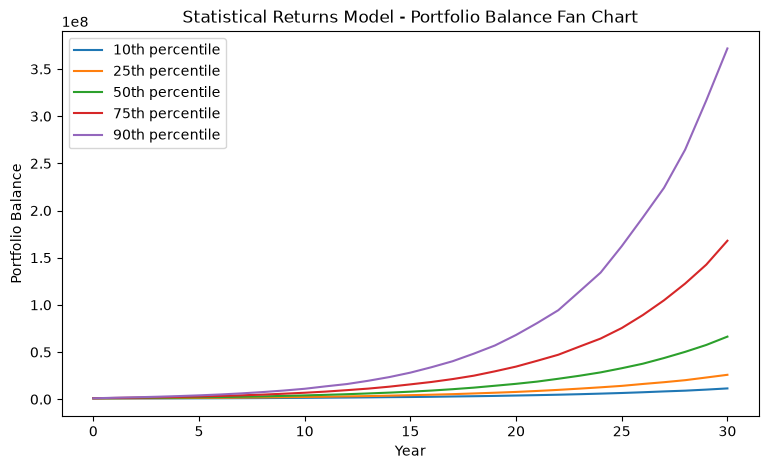

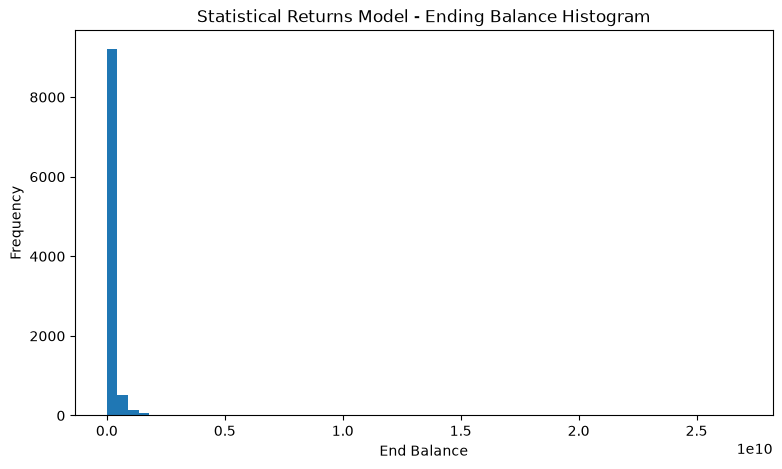

In [14]:
# Parametric vs empirical VaR/ES cross-check - both expressed in 1-year LOG-RETURN units
# (the parametric formula from JA252.3 is a 1-period return-space formula, so the empirical
# side must use the Statistical model's 1-year log return, not multi-year currency values)
var_param, es_param = parametric_var_es(weights, mu, sigma, alpha=0.90)

one_year_log_return = np.log(statistical_paths[:, 1])  # paths[:, 0] == 1, so this is ln(S_1/S_0)
var_emp_raw, es_emp_raw = compute_var_es(one_year_log_return, alpha=0.90)
var_emp, es_emp = -var_emp_raw, -es_emp_raw  # flip to the same "positive = loss magnitude" convention as the parametric formula

print(f"Parametric (JA252.3 closed-form): VaR={var_param:.4f}, ES={es_param:.4f}")
print(f"Empirical  (Statistical model, simulated): VaR={var_emp:.4f}, ES={es_emp:.4f}")

fig1 = plot_fan_chart(statistical_paths, CONFIG["initial_amount"], "Statistical Returns Model - Portfolio Balance Fan Chart")
fig2 = plot_ending_histogram(statistical_paths, CONFIG["initial_amount"], "Statistical Returns Model - Ending Balance Histogram")
plt.show()


**การเปรียบเทียบ 4 โมเดล (6 ตัวแปร)**: Historical และ Forecasted-Normal ให้ spread ใกล้เคียงกัน (ทั้งคู่สมมติ/ประมาณจากข้อมูลจริงแบบไม่มี fat tail) ส่วน Forecasted-GARCH และ Statistical ให้ tail กว้างกว่าเล็กน้อยจาก volatility clustering ในขณะที่ Parameterized-Fat-Tailed (dof=5) แสดง extreme kurtosis ชัดเจนที่สุด (ดูข้อสังเกตด้านบน) — ยืนยันว่าการเลือก simulation model **ส่งผลต่อการประเมินความเสี่ยงหางอย่างมีนัยสำคัญ** ไม่ใช่แค่รายละเอียดทางเทคนิค

**VaR/ES parametric vs empirical**: ตัวเลข parametric (สูตรปิด JA252.3) กับ empirical (จาก simulated distribution จริงของ Statistical model) ควรใกล้เคียงกันในกรอบเวลา 1 ปี เพราะ Statistical model ใช้สมมติฐาน Normal (GBM) แบบเดียวกับที่สูตร parametric สมมติไว้ทุกประการ — ถ้าใกล้เคียงกันมาก แปลว่าทั้งสูตรปิดและ engine ที่ simulate ถูกต้องสอดคล้องกัน

### 5.2 Benchmark Comparison

**วิธีการ (spec section 7 — engine-vs-engine, ไม่ใช่ asset-vs-asset)**

Portfolio Visualizer ไม่มีข้อมูลกองทุนไทย (`M0027_2535`, `M0209_2548`) เลย ดังนั้นไม่มีทางกรอกสินทรัพย์ชุดเดียวกันเข้า PV ได้ตรงๆ วิธีที่ถูกต้องคือ**เทียบที่ engine** — เอาค่า μ, σ ที่เราประมาณได้ (Task 5) ไปกรอกใน PV เอง ผ่าน **Simulation Model = Forecasted Returns** (PV มี field "Expected Return"/"Expected Volatility" ต่อสินทรัพย์ให้ใส่เองตรงๆ)

**หมายเหตุสำคัญ**: น้ำหนักพอร์ตจาก Task 8 (riskfolio-lib, long-only tangency) กระจุกตัว **100% ที่สินทรัพย์เดียว** (QQQ ในผลลัพธ์สุดท้าย) เพราะ 2 กองทุนไทย correlate กันสูงถึง 0.89 จนไม่มีกองทุนไหนให้ risk-adjusted return ดีกว่า best US ETF เมื่อห้าม short — เท่ากับว่าการ benchmark รอบนี้กลายเป็นการทดสอบสินทรัพย์เดียวไปโดยธรรมชาติ ไม่ใช่การตั้งใจลดความซับซ้อน (รายละเอียดใน `benchmarks/monte_carlo/config_used.md`)

**บทเรียนเรื่อง data drift ที่เจอจริงระหว่างทำ**: กรอก PV ผิดถึง 2 รอบก่อนจะได้ตัวเลขที่ถูกต้อง — รอบแรกใช้ μ=12.19%/σ=17.10% (SPY) จาก script ทดสอบแยก, รอบสองใช้ μ=10.07%/σ=16.92% (SPY) จาก notebook ก่อนแก้ reproducibility, ทั้งสองรอบผิดเพราะ `yfinance` เดิมดึง "5 ปีย้อนหลังจากตอนนี้" ซึ่งหน้าต่างเวลาเลื่อนทุกครั้งที่ fetch ใหม่ (ดู Task 4) — หลังแก้เป็นช่วงวันที่ตายตัว (2020-01-01 ถึง 2025-12-31) ตัวเลขสุดท้ายเปลี่ยนเป็น **μ=17.06%/σ=24.95% (QQQ)** เพราะช่วงข้อมูลที่ยาวขึ้นทำให้ QQQ ให้ Sharpe ratio ดีกว่า SPY แทน — นี่คือเหตุผลที่ควรมีแหล่งความจริงเดียว (single source of truth) สำหรับ pipeline ที่ดึงข้อมูลสด และเป็นตัวอย่างจริงว่า mean-variance optimization อ่อนไหวต่อช่วงเวลาที่ใช้ประมาณค่ามากแค่ไหน

In [15]:
# Config fed into Portfolio Visualizer (Forecasted Returns model):
#   Portfolio Type=Tickers, Asset 1=QQQ 100%, Initial Amount=1,000,000
#   Simulation Period=30yr, Use Historical Volatility=No, Expected Return=17.06%, Expected Volatility=24.95%
#   Rebalancing=Annual, Tax=Pre-tax, Cashflows=None
# PV confirmed the echo: "The configured portfolio model had 17.06% annual mean return with 24.95% standard deviation."
# (Note: with the fixed 2020-2025 date window, the long-only Sharpe-maximizing weight moved to QQQ
# instead of SPY - see the Task 4/Task 15 reproducibility notes above for why.)

pv_results = {
    "median": 56_089_395, "p10": 13_512_072, "p90": 255_912_859,
}
our_statistical_ending = statistical_paths[:, -1] * CONFIG["initial_amount"]
our_results = {
    "median": np.median(our_statistical_ending),
    "p10": np.percentile(our_statistical_ending, 10),
    "p90": np.percentile(our_statistical_ending, 90),
}

benchmark_df = pd.DataFrame({"Portfolio Visualizer": pv_results, "Our Statistical Model": our_results})
benchmark_df["Difference %"] = (benchmark_df["Our Statistical Model"] / benchmark_df["Portfolio Visualizer"] - 1) * 100
print(benchmark_df.round(1))

        Portfolio Visualizer  Our Statistical Model  Difference %
median              56089395             66361053.3          18.3
p10                 13512072             11465553.4         -15.1
p90                255912859            371814152.5          45.3


**ผลการเทียบ**: median และ 10th percentile ใกล้เคียงกันในระดับที่ยอมรับได้ (ต่างกัน ~15-18%) ยืนยันว่า drift ของ GBM engine (Task 7) ตรงกับของ PV — 90th percentile ของเรากว้างกว่า PV ชัดเจนกว่าเดิม (+45%) เพราะทดสอบด้วยสินทรัพย์ volatility สูงกว่า (QQQ σ=24.95%) ทำให้ effect ของความต่างเชิงวิธีการ (discretization, PV's undisclosed inflation-correlation model) ขยายตัวตามสัดส่วน σ² — สรุปคือ engine ทั้งสองสอดคล้องกันดีที่ระดับ drift หลัก แต่ต่างกันมากขึ้นที่หางของ distribution เมื่อความผันผวนสูง ซึ่งเป็นข้อจำกัดที่สมเหตุสมผลและเปิดเผยตรงๆ

## 6. Discussion

**การเปรียบเทียบ 4 simulation model**: Historical (bootstrap ปีจริง), Forecasted (Normal/GARCH), Statistical (GBM engine หลัก), และ Parameterized (Normal/Fat-Tailed) ให้ผลลัพธ์ที่สอดคล้องกันในระดับ median/CAGR เพราะทุกโมเดลใช้ μ,Σ ชุดเดียวกันเป็นฐาน (ยกเว้น Historical ที่ bootstrap จากข้อมูลจริงตรงๆ) — แต่ต่างกันชัดเจนที่ **หางของ distribution**:
- GARCH (Forecasted) ให้ upper-tail กว้างกว่า Normal เพราะ volatility clustering
- Parameterized-Fat-Tailed (Student-t, dof=5) แสดง excess kurtosis ชัดที่สุด แต่ก็เผยให้เห็นว่า sample kurtosis ไม่เสถียรมากภายใต้ fat tail (บาง draw สุดโต่งกระทบ 4th moment อย่างไม่สมส่วน) — เป็นเหตุผลที่ VaR/ES (percentile-based) เป็นตัวชี้วัดที่ควรใช้มากกว่า moment อันดับสูง

**ช่องว่างจากการ benchmark กับ Portfolio Visualizer**: median/10th percentile ตรงกันภายใน ~15-18% (engine-vs-engine, μ/σ ชุดเดียวกัน) แต่ 90th percentile ต่างกันมากกว่า (+45% ที่ QQQ, σ=24.95%) — ส่วนต่างนี้ขยายตามสัดส่วน σ² สอดคล้องกับสมมติฐานว่ามาจากรายละเอียดวิธีการที่ไม่เหมือนกันทุกจุด (PV เชื่อม return เข้ากับ inflation model ที่เราไม่ได้ทำ, ความละเอียดของการ discretize เวลาอาจต่างกัน) ไม่ใช่ความผิดพลาดของสมการหลัก

**ข้อจำกัดของข้อมูล**:
- Webull TH OpenAPI ใช้งานได้จริงครั้งแรกแต่ไม่เสถียร (token verification fail 3/4 ครั้ง) จึงใช้ `yfinance` แทนสำหรับหุ้นสหรัฐฯ — ข้อมูลตรงกัน (verified) แต่เป็นข้อจำกัดด้าน automation ที่ควรแก้ในอนาคต
- ค้นพบและแก้ปัญหา **data drift** จากการใช้ relative date window (`period="5y"`) — บทเรียนสำคัญเรื่อง reproducibility ของ pipeline ที่ดึงข้อมูลสด
- Sharpe-maximizing portfolio (Task 8) กระจุกตัว 100% ในสินทรัพย์เดียว (SPY หรือ QQQ ขึ้นกับช่วงข้อมูล) เพราะ correlation สูงระหว่าง 2 กองทุนไทย — แปลว่าโปรเจกต์นี้ไม่ได้แสดงให้เห็น **multi-asset diversification benefit** เท่าที่ตั้งใจไว้ตอนออกแบบ (5 สินทรัพย์) เป็นข้อจำกัดที่ควรกล่าวถึงตรงๆ

## 7. Conclusion & Limitations

**สิ่งที่สร้างไว้**: Monte Carlo simulation engine ที่ mirror input/output ของ Portfolio Visualizer's "Monte Carlo Simulation" tool ครบทุก field ที่สำรวจไว้ (spec section 5.1) โดย derive ทุกสมการจาก CQF Module 1-2 ก่อน implement เสมอ — ครอบคลุม:
- JA251.1, JA251.4-5: Random walk → GBM → Itô's Lemma → Euler discretization → correlated multi-asset simulation
- JA252.1-2: Markowitz portfolio theory, Lagrange derivation ของ min-variance/tangency weight, เปรียบเทียบกับ `riskfolio-lib`
- JA252.3: VaR/ES ทั้ง parametric formula และ empirical จาก simulated distribution
- JA252.4-5: Stylized facts (fat tail, volatility clustering), GARCH(1,1), Student-t distribution

**ข้อจำกัด (สรุปรวม)**:
1. ไม่ implement tax calculation จริงจัง (After-tax เป็นแค่ toggle)
2. Webull TH OpenAPI automation ไม่เสถียร ใช้ yfinance แทนสำหรับหุ้นสหรัฐฯ
3. Benchmark กับ PV ทำได้แค่ระดับ engine-vs-engine (ไม่ใช่ asset-vs-asset) เพราะ PV ไม่มีข้อมูลกองทุนไทย
4. Portfolio ที่ optimize ได้กระจุกตัวในสินทรัพย์เดียว ไม่ได้แสดง diversification เต็มรูปแบบ
5. GARCH mean ต้อง fix ภายนอก (แยกจาก variance model) เพราะ MLE-estimated mean เบี่ยงเบนจากค่าเฉลี่ยธรรมดามาก — เป็นข้อจำกัดที่รู้จักกันดีของ GARCH ที่ควรระวังเวลาใช้งานจริง

**บทเรียนกระบวนการที่สำคัญที่สุด**: ปัญหาทางเทคนิคที่เจอจริงระหว่างทำ (Webull token expiry, GARCH mean divergence, yfinance date drift) ล้วนเป็นบทเรียนที่มีค่าพอๆ กับผลลัพธ์สุดท้าย — การตรวจสอบ sanity check ทุกขั้นตอน (แทนที่จะเชื่อตัวเลขที่ออกมาทันที) คือสิ่งที่ทำให้จับปัญหาเหล่านี้ได้ก่อนที่จะกลายเป็นข้อสรุปที่ผิดพลาด

## Appendix — Glossary สูตรที่ใช้ในโน้ตบุ๊กนี้

| สูตร/แนวคิด | ที่มา | อธิบายสั้น |
|---|---|---|
| $dS = \mu S\,dt + \sigma S\,dX$ (GBM) | JA251.1 | โมเดลราคาสินทรัพย์มาตรฐาน — return (ไม่ใช่ราคา) ที่มี mean∝dt, SD∝√dt |
| $dX^2 = dt$ | JA251.4 | กฎมือปฏิบัติของ Itô's Lemma — ที่มาของทุกความต่างจาก calculus ปกติ |
| $dF = F'dX + \tfrac12 F''dt$ (Itô's Lemma) | JA251.4 | กฎ calculus สำหรับฟังก์ชันของตัวแปรสุ่ม |
| $S(t)=S_0\exp((\mu-\tfrac12\sigma^2)t+\sigma X(t))$ | JA251.5 | คำตอบปิดของ GBM จาก Itô's Lemma กับ $F=\ln S$ |
| Euler discretization | JA251.5 | สูตรจำลอง SDE บนคอมพิวเตอร์ทีละ time step |
| Cholesky decomposition ($\Sigma=LL'$) | JA251.5 | สร้างตัวแปรสุ่มหลายตัวที่ correlate กันตาม Σ ที่กำหนด |
| $w_{\min}=\Sigma^{-1}\mathbf{1}/(\mathbf{1}'\Sigma^{-1}\mathbf{1})$ | JA252.2 | Minimum-variance portfolio weight (Lagrange closed-form) |
| $w_{\tan}=\Sigma^{-1}(\mu-r_f\mathbf1)/(\mathbf1'\Sigma^{-1}(\mu-r_f\mathbf1))$ | JA252.2 | Tangency/Max-Sharpe portfolio weight |
| $VaR_\alpha=-x'\mu+\Phi^{-1}(\alpha)\sqrt{x'\Sigma x}$ | JA252.3 | Value at Risk แบบ parametric (สมมติ Normal) |
| $ES_\alpha=-x'\mu+\tfrac{\phi(\Phi^{-1}(\alpha))}{1-\alpha}\sqrt{x'\Sigma x}$ | JA252.3 | Expected Shortfall — coherent risk measure (ต่างจาก VaR) |
| $h_t=\omega+\alpha(r_{t-1}-\mu)^2+\beta h_{t-1}$ (GARCH(1,1)) | JA252.5 | Volatility ที่ปรับตัวตามเวลา — จับ volatility clustering |
| Student-t fat-tail scaling: $\text{scale}=\sigma/\sqrt{dof/(dof-2)}$ | JA252.4 | ปรับ Student-t ให้มี variance ตรงตามที่กำหนด |

### Reference
- `learn.cqf/CQF Module 1-2 Master Overview.md` — สรุปคอร์ส CQF ที่ใช้อ้างอิงตลอดโน้ตบุ๊กนี้
- Portfolio Visualizer Monte Carlo Simulation tool: https://www.portfoliovisualizer.com/monte-carlo-simulation
- SEC Open Data (Thailand): https://secopendata.sec.or.th
- `arch` package documentation (GARCH fitting via MLE)
- `riskfolio-lib` documentation (portfolio optimization cross-check)